Basit RNN kullanarak model oluşturmak istiyoruz.

 - Çalışma zamanı çökmelerini de önlemek için yüksek RAM ve GPU için ColabPro ile L4 GPU çeşidini kullanıyoruz.

In [ ]:
import pandas as pd  # Tabloları (CSV) okumak ve düzenlemek için.
import numpy as np   # Sayısal hesaplamalar ve matris işlemleri için.
import matplotlib.pyplot as plt # Grafik ve tablo çizdirmek için.
import seaborn as sns # Renkli ve detaylı analiz grafikleri için.
import re             # Metin içindeki gereksiz karakterleri temizlemek için.
from nltk.corpus import stopwords # "the, a, is" gibi anlamsız kelimeleri atmak için.
from wordcloud import WordCloud  # En çok geçen kelimeleri görselleştirmek için.
from tensorflow.keras.preprocessing.text import Tokenizer # Kelimeleri sayılara çevirmek (sözlük) için.
from tensorflow.keras.preprocessing.sequence import pad_sequences # Tüm metinleri aynı uzunluğa getirmek için.
from sklearn.model_selection import train_test_split # Veriyi eğitim ve test olarak ikiye bölmek için.
from tensorflow.keras.models import Sequential # Katmanları sırayla dizmek için ana iskelet.
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout # Modelin öğrenme ve karar katmanları.
from tensorflow.keras.callbacks import EarlyStopping # Model ezberlemeye başlarsa eğitimi durdurmak için.
from tensorflow.keras.optimizers import Adam # Hataları düzelterek öğrenmeyi sağlayan mekanizma.
from sklearn.metrics import classification_report, confusion_matrix # Başarıyı ölçmek ve hataları görmek için.

- Veri setini kaggle üzerinden bulduk.

https://www.kaggle.com/datasets/rmisra/news-category-dataset/data

- Veri seti json dosyası şeklinde olduğundan read_json ile veriye ulaşıyoruz.

In [ ]:
df= pd.read_json("/content/drive/MyDrive/rnn/News_Category_Dataset_v3.json" , lines= True)

- Veri setini incelemek için ilk 5 satırı inceliyoruz.

In [ ]:
df.head(5)

,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


- Veri setindeki feature'lar hakkında bilgi sahibi olmak için info metoduyla detaylara ulaştık.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209527 entries, 0 to 209526
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   link               209527 non-null  object        
 1   headline           209527 non-null  object        
 2   category           209527 non-null  object        
 3   short_description  209527 non-null  object        
 4   authors            209527 non-null  object        
 5   date               209527 non-null  datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 9.6+ MB


- İnfo metondu eksik bilgi olmadığını gördük ama yine de isnull metoduyla sağlıyoruz.

In [ ]:
df.isnull().sum()

,0
link,0
headline,0
category,0
short_description,0
authors,0
date,0


- Veri seti açıklamalarında 40 çeşit kategori olduğu belirtiliyor. Tek tek görüü incelemek için unique metodunu kullanıyoruz.

In [ ]:
print(df['category'].unique())

['U.S. NEWS' 'COMEDY' 'PARENTING' 'WORLD NEWS' 'CULTURE & ARTS' 'TECH'
 'SPORTS' 'ENTERTAINMENT' 'POLITICS' 'WEIRD NEWS' 'ENVIRONMENT'
 'EDUCATION' 'CRIME' 'SCIENCE' 'WELLNESS' 'BUSINESS' 'STYLE & BEAUTY'
 'FOOD & DRINK' 'MEDIA' 'QUEER VOICES' 'HOME & LIVING' 'WOMEN'
 'BLACK VOICES' 'TRAVEL' 'MONEY' 'RELIGION' 'LATINO VOICES' 'IMPACT'
 'WEDDINGS' 'COLLEGE' 'PARENTS' 'ARTS & CULTURE' 'STYLE' 'GREEN' 'TASTE'
 'HEALTHY LIVING' 'THE WORLDPOST' 'GOOD NEWS' 'WORLDPOST' 'FIFTY' 'ARTS'
 'DIVORCE']


- head metoduyla gördüğümüz gibi link authors ve date sınıfları bizim için gereksiz yani tahminde bir yardımı olmayacağından bu feature'ları veri setinden atıyoruz.

In [ ]:
df = df.drop(columns=['link', 'authors', 'date'])
display(df.head())

,headline,category,short_description
0,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...
1,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...
2,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha..."
3,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to..."
4,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...


- Kategorilerdeki değerlerin sayıları için value_counts ile bunu buluyoruz.

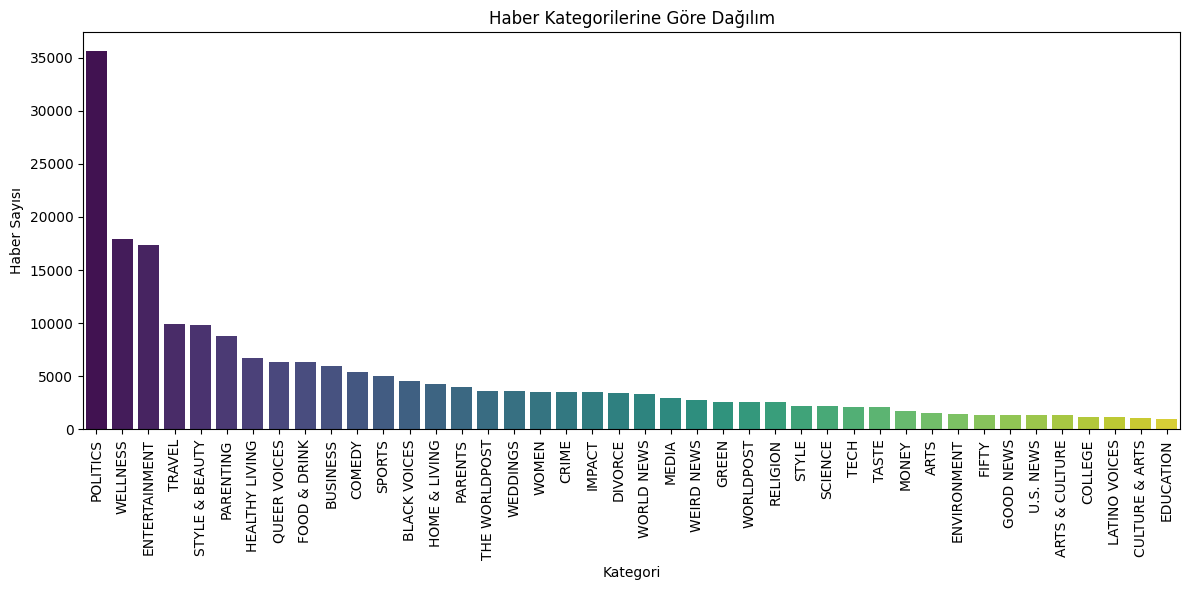

In [ ]:
category_counts = df['category'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=category_counts.index, y=category_counts.values, hue=category_counts.index, palette='viridis', legend=False)
plt.title('Haber Kategorilerine Göre Dağılım')
plt.xlabel('Kategori')
plt.ylabel('Haber Sayısı')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

- Çıktıda görüldüğü gibi en çok politics verisi bulunmaktadır.

- Veri setini daha basite indirgemek amaçlı 3 sınıf seçiyoruz.Bu 3 sınıfı da şu şekilde seçiyoruz.
- Seçtiğimiz sınıflar birbirleriyle çok alakasız olduğundan bu 3 sınıfı seçmek daha mantıklı olabilir düşüncesinden yola çıktık.

In [ ]:
selected = ["SPORTS", "TECH", "POLITICS"]

df_selected = df[df["category"].isin(selected)].copy()

- Eski veri setine belki sonra ihtiyacımız olabilir diye seçilmiş sınıflarımız ile yeni bir dataframe oluşturduk.

In [ ]:
df_selected.info()

<class 'pandas.core.frame.DataFrame'>
Index: 42783 entries, 13 to 209526
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   headline           42783 non-null  object
 1   category           42783 non-null  object
 2   short_description  42783 non-null  object
dtypes: object(3)
memory usage: 1.3+ MB


- Burda categoryleri kesinleştirmek amaçlı yine kontrol ettik.

In [ ]:
print(df_selected['category'].unique())

['TECH' 'SPORTS' 'POLITICS']


- Modelin haberi daha iyi analiz edebilmesi için haber başlığınıü ve kısa özetini tek bir metin bloğunda birleştiriyoruz. Sadece başlığa bakmak bazen yanıltıcı veya yetersiz olabilir bu yüzden özetteki detayları da ekleyerek modelin elindeki ipucu sayısını artırıyoruz.

In [ ]:
df_selected["text"] = df_selected["headline"] + " " + df_selected["short_description"]
display(df_selected.head())

,headline,category,short_description,text
13,Twitch Bans Gambling Sites After Streamer Scam...,TECH,One man's claims that he scammed people on the...,Twitch Bans Gambling Sites After Streamer Scam...
17,"Maury Wills, Base-Stealing Shortstop For Dodge...",SPORTS,"Maury Wills, who helped the Los Angeles Dodger...","Maury Wills, Base-Stealing Shortstop For Dodge..."
21,Biden Says U.S. Forces Would Defend Taiwan If ...,POLITICS,President issues vow as tensions with China rise.,Biden Says U.S. Forces Would Defend Taiwan If ...
24,‘Beautiful And Sad At The Same Time’: Ukrainia...,POLITICS,An annual celebration took on a different feel...,‘Beautiful And Sad At The Same Time’: Ukrainia...
26,"Las Vegas Aces Win First WNBA Title, Chelsea G...",SPORTS,Las Vegas never had a professional sports cham...,"Las Vegas Aces Win First WNBA Title, Chelsea G..."


- Aşağıdaki fonksiyon modelin kafasını karıştıracak bütün kalabalığı metinden atıyor önce her şeyi küçük harf yapıyor ki Apple ile apple kelimesini farklı bir şey sanmasın sonra işimize yaramayan internet linklerini ve sayı ya da nokta gibi işaretleri siliyor böylece model sadece harflere ve kelimelere odaklanıp çok daha rahat öğreniyor yani kısaca veriyi tertemiz edip modeli gereksiz detaydan kurtarıyor.

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

-  burda da clean edilmiş veriyi selected edilen dataframe'e ekledik.

In [ ]:
df_selected["text"] = df_selected["text"].apply(clean_text)
display(df_selected.head())

,headline,category,short_description,text
13,Twitch Bans Gambling Sites After Streamer Scam...,TECH,One man's claims that he scammed people on the...,twitch bans gambling sites after streamer scam...
17,"Maury Wills, Base-Stealing Shortstop For Dodge...",SPORTS,"Maury Wills, who helped the Los Angeles Dodger...",maury wills basestealing shortstop for dodgers...
21,Biden Says U.S. Forces Would Defend Taiwan If ...,POLITICS,President issues vow as tensions with China rise.,biden says us forces would defend taiwan if ch...
24,‘Beautiful And Sad At The Same Time’: Ukrainia...,POLITICS,An annual celebration took on a different feel...,beautiful and sad at the same time ukrainian c...
26,"Las Vegas Aces Win First WNBA Title, Chelsea G...",SPORTS,Las Vegas never had a professional sports cham...,las vegas aces win first wnba title chelsea gr...


- Alttaki kodla metindeki bütün gereksiz kelimeleri ayıklıyoruz yani ingilizcedeki the is and gibi tek başına hiçbir anlamı olmayan ve modelin kafasını boşuna şişiren kelimeleri çöpe atıyoruz.Ve bu işlemleri stopwords ile yapıyoruz.Sadece spor teknoloji veya siyaset gibi asıl konuyu anlatan önemli kelimeler elimizde kalıyor böylece model gereksiz kalabalıkla uğraşmıyor ve çok daha temiz veriyle doğru tahmini daha kolay yapıyor.

In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
stop_words = set(stopwords.words("english"))
def remove_stopwords(text):
    return " ".join([w for w in text.split() if w not in stop_words])

#join() diyerek o kelimeleri aralarına birer boşluk koyup tekrar "apple released update" şeklinde birleştiriyoruz.

df_selected["text"] = df_selected["text"].apply(remove_stopwords)
display(df_selected.head())

,headline,category,short_description,text
13,Twitch Bans Gambling Sites After Streamer Scam...,TECH,One man's claims that he scammed people on the...,twitch bans gambling sites streamer scams folk...
17,"Maury Wills, Base-Stealing Shortstop For Dodge...",SPORTS,"Maury Wills, who helped the Los Angeles Dodger...",maury wills basestealing shortstop dodgers die...
21,Biden Says U.S. Forces Would Defend Taiwan If ...,POLITICS,President issues vow as tensions with China rise.,biden says us forces would defend taiwan china...
24,‘Beautiful And Sad At The Same Time’: Ukrainia...,POLITICS,An annual celebration took on a different feel...,beautiful sad time ukrainian cultural festival...
26,"Las Vegas Aces Win First WNBA Title, Chelsea G...",SPORTS,Las Vegas never had a professional sports cham...,las vegas aces win first wnba title chelsea gr...


- Kısa verilerin yanlış yönlendirmemesi için 3 kelimeden kısa olan satırları siliyoruz.

In [ ]:
df_selected = df_selected[df_selected["text"].str.split().str.len() > 3]
display(df_selected.head())

,headline,category,short_description,text
13,Twitch Bans Gambling Sites After Streamer Scam...,TECH,One man's claims that he scammed people on the...,twitch bans gambling sites streamer scams folk...
17,"Maury Wills, Base-Stealing Shortstop For Dodge...",SPORTS,"Maury Wills, who helped the Los Angeles Dodger...",maury wills basestealing shortstop dodgers die...
21,Biden Says U.S. Forces Would Defend Taiwan If ...,POLITICS,President issues vow as tensions with China rise.,biden says us forces would defend taiwan china...
24,‘Beautiful And Sad At The Same Time’: Ukrainia...,POLITICS,An annual celebration took on a different feel...,beautiful sad time ukrainian cultural festival...
26,"Las Vegas Aces Win First WNBA Title, Chelsea G...",SPORTS,Las Vegas never had a professional sports cham...,las vegas aces win first wnba title chelsea gr...


##### Wordcloud
- Metinlerin içerisinde en sık tekrar eden kelimeleri tespit ederek, bu kelimeleri kullanım sıklığına göre daha büyük ve belirgin şekilde, az geçenleri ise daha küçük puntolarla bir araya getirir. Bu görselleştirmeyi yapmamızın asıl amacı, verinin genel karakterini ve hangi konuların baskın olduğunu ilk bakışta anlayabilmektir.

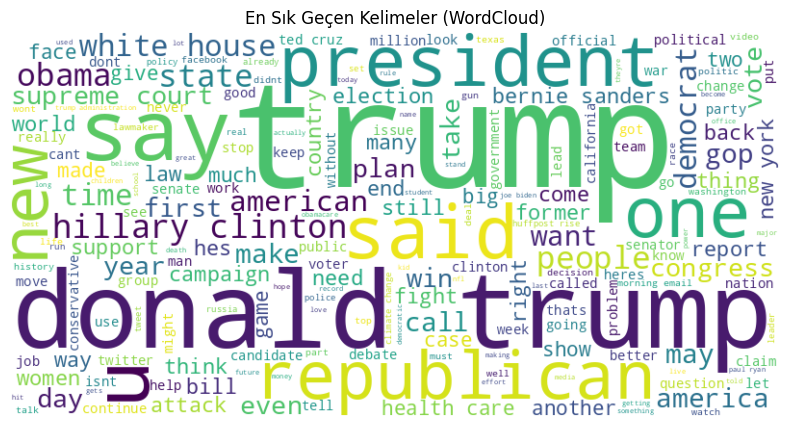

In [ ]:
# Bütün satırlardaki metinleri aralarına boşluk koyarak tek bir dev metin yapar
all_text = ' '.join(df_selected['text'])

# Kelimelerin büyüklüğüne göre kelime bulutu resmini oluşturur
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# Oluşan resmi ekranda gösterme ayarlarını yapar
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear') # Resmi pürüzsüzleştirerek ekrana basar
plt.axis('off') # Kenardaki gereksiz koordinat sayılarını gizler
plt.title('En Sık Geçen Kelimeler (WordCloud)') # Grafik başlığını ekler
plt.show() # Final resmini ekrana yansıtır

- Yukarda veri setini toplu olarak aldık.
- Altta her kategori için ayrı ayrı wordcloud oluşturuyoruz.

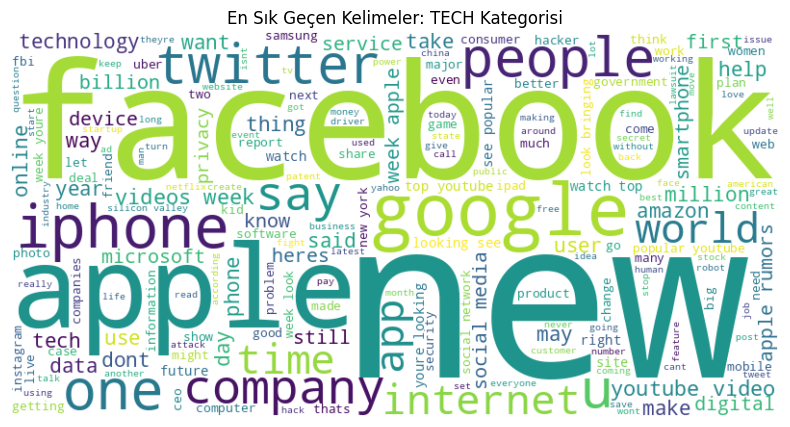

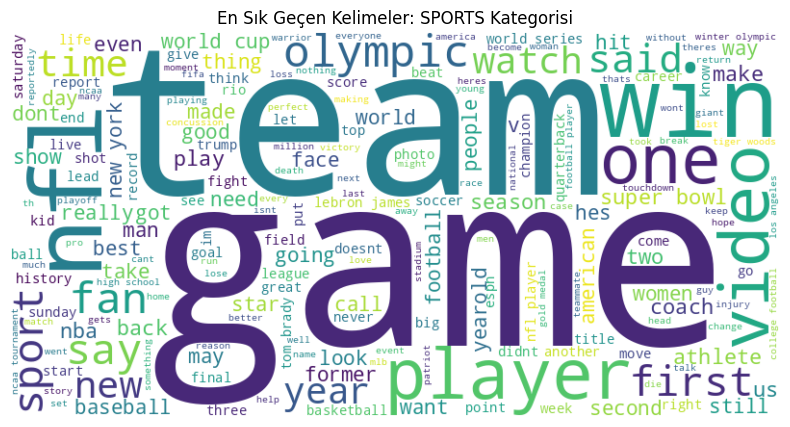

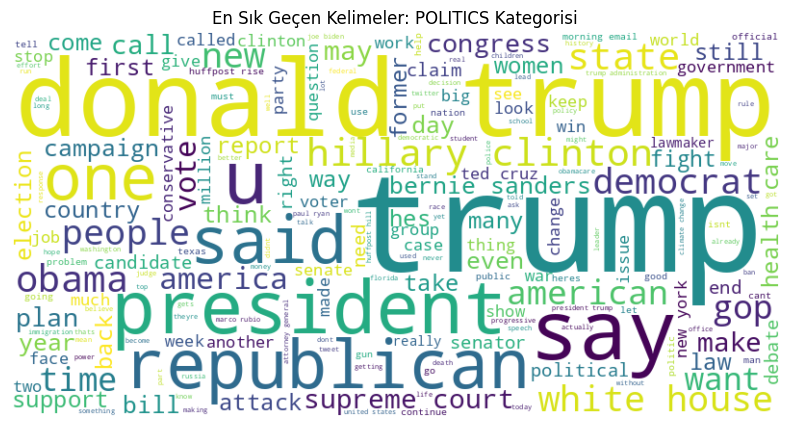

In [ ]:
# Get unique categories
categories = df_selected['category'].unique()

for category in categories:
    # Filter DataFrame for the current category
    category_df = df_selected[df_selected['category'] == category]

    # Combine all text for the current category
    all_category_text = ' '.join(category_df['text'])

    # Generate a word cloud image for the current category
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_category_text)

    # Display the generated image:
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'En Sık Geçen Kelimeler: {category} Kategorisi')
    plt.show()

- Alttaki koda mapping yapıyoruz.
- Bilgisayarlar kelimelerden değil sayılardan anlar bu yüzden kategorileri sayılara çeviriyoruz örneğin spor haberlerini 0 teknoloji haberlerini 1 olarak etiketliyoruz ki model bunları matematiksel olarak işleyip öğrenebilsin yani kısaca kategorileri makinenin diline tercüme ediyoruz.

In [ ]:
label_map = {
    "SPORTS": 0,
    "TECH": 1,
    "POLITICS": 2
}

df_selected["label"] = df_selected["category"].map(label_map)
display(df_selected.head())

,headline,category,short_description,text,label
13,Twitch Bans Gambling Sites After Streamer Scam...,TECH,One man's claims that he scammed people on the...,twitch bans gambling sites streamer scams folk...,1
17,"Maury Wills, Base-Stealing Shortstop For Dodge...",SPORTS,"Maury Wills, who helped the Los Angeles Dodger...",maury wills basestealing shortstop dodgers die...,0
21,Biden Says U.S. Forces Would Defend Taiwan If ...,POLITICS,President issues vow as tensions with China rise.,biden says us forces would defend taiwan china...,2
24,‘Beautiful And Sad At The Same Time’: Ukrainia...,POLITICS,An annual celebration took on a different feel...,beautiful sad time ukrainian cultural festival...,2
26,"Las Vegas Aces Win First WNBA Title, Chelsea G...",SPORTS,Las Vegas never had a professional sports cham...,las vegas aces win first wnba title chelsea gr...,0


-  Rastgele 5 örnek alıp son kez veriyi inceliyoruz.

In [ ]:
df_selected.sample(5)

,headline,category,short_description,text,label
58049,"Jailed Over Traffic Tickets, This Mother Attem...",POLITICS,"""You never know how a person would feel when b...",jailed traffic tickets mother attempted suicid...,2
54362,Trump Distorted What's Going On With Obamacare...,POLITICS,"Obamacare has its problems, but Trump is full ...",trump distorted whats going obamacare usual ob...,2
93575,Congress Wants Teenagers To Drive Big Rigs,POLITICS,A provision in a new bill would let younger tr...,congress wants teenagers drive big rigs provis...,2
30374,"Medicare For All Is Coming, No Matter What The...",POLITICS,Why is the nation that used to pride itself on...,medicare coming matter say nation used pride c...,2
12332,Bernie Sanders’ Economic Inequality Town Hall ...,POLITICS,The Vermont senator is using his reach to try ...,bernie sanders economic inequality town hall d...,2


#### Tokenizing
- Tokenizing ile kelimeleri sözlükteki karşılığı olan sayılara çeviririz.

In [ ]:
# En sık kullanılan 10.000 kelimeyi baz alalım
max_words = 10000
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")

# Tokenizer'ı df_selected'daki temizlenmiş metinler üzerinde eğitelim
tokenizer.fit_on_texts(df_selected["text"])

# Cümleleri sayı dizilerine çevir
sequences = tokenizer.texts_to_sequences(df_selected["text"])

print("Örnek metin dizisi:")
print(sequences[0])

print("\nİlk 10 kelime ve indeksleri:")
for word, index in list(tokenizer.word_index.items())[:10]:
    print(f"{word}: {index}")

Örnek metin dizisi:
[1, 1865, 4423, 2406, 1, 1, 1891, 12, 3678, 224, 1, 14, 1375, 2600, 621, 714, 1, 992, 1, 2601]

İlk 10 kelime ve indeksleri:
<OOV>: 1
trump: 2
donald: 3
trumps: 4
new: 5
president: 6
us: 7
said: 8
says: 9
gop: 10


#### Padding
- Tüm cümleleri aynı boya getirmek için padding işlemi yapıyoruz ve max length i 30'a sabitliyoruz.

In [ ]:
max_len = 30 # Her haberi 30 kelimeye sabitleyelim (Embedding katmanı ile uyumlu hale getirildi)
X = pad_sequences(sequences, maxlen=max_len, padding="pre", truncating="post")

print("Padlenmiş ilk metin dizisi:")
print(X[0])
print(f"Tüm dizilerin şekli: {X.shape}")

Padlenmiş ilk metin dizisi:
[   0    0    0    0    0    0    0    0    0    0    1 1865 4423 2406
    1    1 1891   12 3678  224    1   14 1375 2600  621  714    1  992
    1 2601]
Tüm dizilerin şekli: (42583, 30)


#### Veriyi train test diye bölme

In [ ]:
y = df_selected["label"].values # Sayıya çevirdiğin etiketler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train boyutu: {X_train.shape}")
print(f"X_test boyutu: {X_test.shape}")
print(f"y_train boyutu: {y_train.shape}")
print(f"y_test boyutu: {y_test.shape}")

X_train boyutu: (34066, 30)
X_test boyutu: (8517, 30)
y_train boyutu: (34066,)
y_test boyutu: (8517,)


#### MODEL OLUŞTURMA
-  Veri setini oluşturduğumuz için model oluşturma kısmına geçiyoruz.


- Output_dim ilk başta 128 di bunu 50 ye indirerek daha iyi öğrenen bir model oluşturuldu.

- Güven oranını arttırmak için dropout değerini arttırdım.

In [ ]:
# Modelin iskeletini oluşturuyoruz
model = Sequential()

# 1. Katman: Embedding (Kelimeleri anlamlı vektörlere çevirir)
# max_words: Sözlük boyutu, 128: Her kelimenin temsil edileceği vektör boyutu
model.add(Embedding(input_dim=10000, output_dim=50))

# 2. Katman: SimpleRNN (Metindeki sıralı bilgiyi işler)
# 64 nöronlu bir RNN katmanı
model.add(SimpleRNN(64,dropout=0.3,recurrent_dropout=0.3))

# 3. Katman: Dropout (Ezberlemeyi/Overfitting'i önlemek için bazı nöronları rastgele kapatır)
model.add(Dropout(0.5))

# 4. Katman: Çıkış Katmanı (Kategori tahmini)
# Eğer 3 kategorin varsa '3', aktivasyon 'softmax' (olasılık üretmesi için)
model.add(Dense(3, activation='softmax'))

- İlk başta learning rate oranı yüksekti ve model çok hızlı ilerliyordu bunu önlemek için learning rate'i düşürerek yavaş ilerleme sağlıyoruz.

In [ ]:
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Modelin özetini görelim
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_12 (SimpleRNN)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

- Model şuan boş olduğundan çıktı da boş oluyor.

- Overfittingi önlemek için early stopping mekanizmasını ekliyoruz.

- Elde edilen ilk sonuçları iyileştirmek için batch_size'ı 32 den 64 e çıkardık.

In [ ]:
# Early Stopping tanımlıyoruz
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True # Eğitim durduğunda en iyi ağırlıkları kaydeder.
)

# Modeli eğitirken callback olarak ekliyoruz
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5873 - loss: 0.9446 - val_accuracy: 0.8309 - val_loss: 0.5979
Epoch 2/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7831 - loss: 0.6948 - val_accuracy: 0.8309 - val_loss: 0.6091
Epoch 3/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8087 - loss: 0.6566 - val_accuracy: 0.8309 - val_loss: 0.5924
Epoch 4/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8182 - loss: 0.6404 - val_accuracy: 0.8309 - val_loss: 0.5849
Epoch 5/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8238 - loss: 0.6283 - val_accuracy: 0.8309 - val_loss: 0.5797
Epoch 6/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8286 - loss: 0.6082 - val_accuracy: 0.8309 - val_loss: 0.5751
Epoch 7/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8305 - loss: 0.6018 - val_accuracy: 0.8309 - val_loss: 0.5725
Epoch 8/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8318 - loss: 0.5935 - val_accuracy: 0

- 20 epochs'la model eğitimini tamamlıyoruz.

- Modelin loss değerleri için grafik oluşturuyoruz.

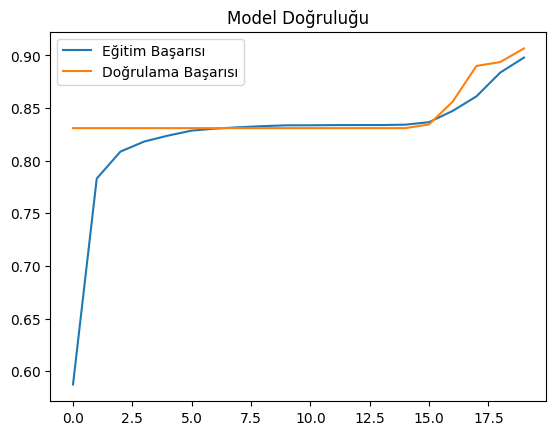

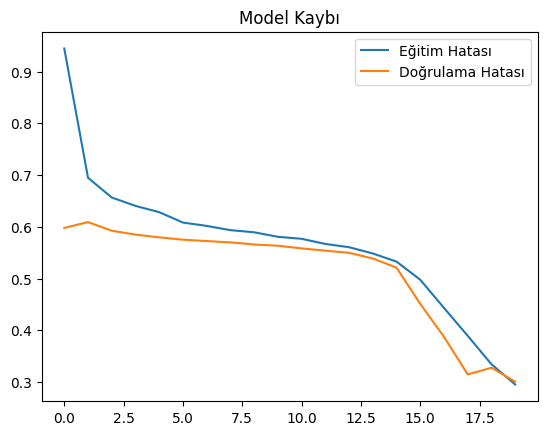

In [ ]:
# Accuracy (Doğruluk) grafiği
plt.plot(history.history['accuracy'], label='Eğitim Başarısı')
plt.plot(history.history['val_accuracy'], label='Doğrulama Başarısı')
plt.title('Model Doğruluğu')
plt.legend()
plt.show()

# Loss (Hata) grafiği
plt.plot(history.history['loss'], label='Eğitim Hatası')
plt.plot(history.history['val_loss'], label='Doğrulama Hatası')
plt.title('Model Kaybı')
plt.legend()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Seti Doğruluğu: %{test_acc * 100:.2f}")

267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9023 - loss: 0.3025
Test Seti Doğruluğu: %90.23


- Testin doğruluk değeri 90 çıkıyor.

In [ ]:
def predict_category(text):
    # 1. Metni Temizle (Daha önce yazdığın fonksiyonları kullanıyoruz)
    cleaned = clean_text(text)
    no_stopwords = remove_stopwords(cleaned)

    # 2. Tokenization (Eğitimde kullandığın 'tokenizer' nesnesini kullanmalısın)
    seq = tokenizer.texts_to_sequences([no_stopwords])

    # 3. Padding (Eğitimde kullandığın 'max_len' değerini kullan)
    padded = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')

    # 4. Tahmin Yap
    prediction = model.predict(padded)

    # 5. En yüksek olasılıklı sınıfın indeksini bul
    class_index = np.argmax(prediction)

    # 6. İndeksi tekrar kategori ismine çevir (label_map'in tersi)
    reverse_label_map = {v: k for k, v in label_map.items()}
    category = reverse_label_map.get(class_index, "Bilinmeyen Kategori")

    # Olasılık değerini de görelim
    confidence = np.max(prediction)

    return category, confidence

- Sonradan modelde compile edip sonucunu görmek istediğimiz verileri model için uygun hale getirmek amacıyla üstteki fonksiyonu oluşturduk.

- Alttaki 3 kod bloğunda olduğu gibi cümle verip onları üstteki metoda soktuk.

In [ ]:
sample_news = "The local football team won the championship after a thrilling final match last night."
category, score = predict_category(sample_news)
print(f"Haber: {sample_news}")
print(f"Tahmin Edilen Kategori: {category}")
print(f"Güven Skoru: %{score * 100:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 501ms/step
Haber: The local football team won the championship after a thrilling final match last night.
Tahmin Edilen Kategori: SPORTS
Güven Skoru: %65.33


- İlkinde %65 güven oranıyla doğru tahmin ettik.

In [ ]:
sample_news = "Apple released a new iOS software update for the iPhone to fix security bugs and improve battery life."
category, score = predict_category(sample_news)
print(f"Haber: {sample_news}")
print(f"Tahmin Edilen Kategori: {category}")
print(f"Güven Skoru: %{score * 100:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Haber: Apple released a new iOS software update for the iPhone to fix security bugs and improve battery life.
Tahmin Edilen Kategori: SPORTS
Güven Skoru: %65.02


- %65 güven skoru ile yanlış tahmin etti.

In [ ]:
sample_news = "Donald Trump launched a new campaign for the upcoming election, targeting Republican voters across America."
category, score = predict_category(sample_news)
print(f"Haber: {sample_news}")
print(f"Tahmin Edilen Kategori: {category}")
print(f"Güven Skoru: %{score * 100:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Haber: Donald Trump launched a new campaign for the upcoming election, targeting Republican voters across America.
Tahmin Edilen Kategori: POLITICS
Güven Skoru: %40.44


- %40 güven skoruyla doğru tahmin etti.

In [ ]:
print("\nKategori - Sayı (Label) Eşleşmesi:")
for category_name, label_value in label_map.items():
    print(f"Kategori: {category_name}  --->  Sayı (Label): {label_value}")


Kategori - Sayı (Label) Eşleşmesi:
Kategori: SPORTS  --->  Sayı (Label): 0
Kategori: TECH  --->  Sayı (Label): 1
Kategori: POLITICS  --->  Sayı (Label): 2


-  Bazı yanlışlardan sonra kategori eşleşmelerini kontrol etmek için üstteki kod bloğunu kullandık.

267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Classification Report:
              precision    recall  f1-score   support

      SPORTS       0.72      0.69      0.71      1040
        TECH       0.00      0.00      0.00       421
    POLITICS       0.93      0.99      0.96      7056

    accuracy                           0.90      8517
   macro avg       0.55      0.56      0.55      8517
weighted avg       0.86      0.90      0.88      8517



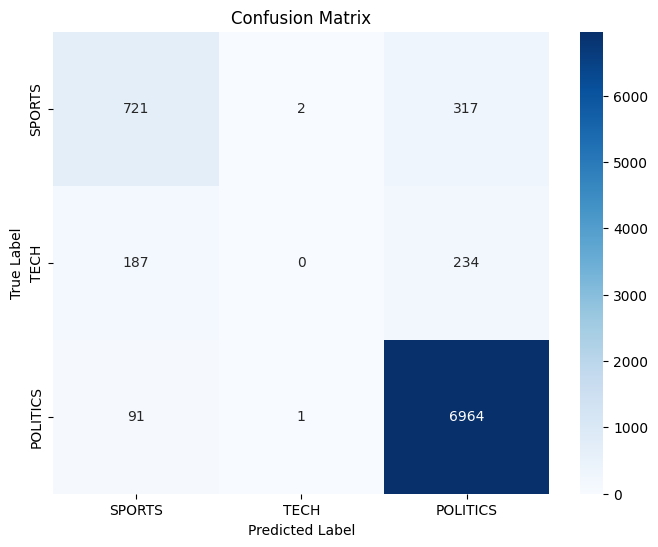

In [ ]:
# Tahminleri al
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Sınıflandırma raporu
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=list(label_map.keys())))

# Karışıklık Matrisi
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(label_map.keys()),
            yticklabels=list(label_map.keys()))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

- Elde edilen sonuçlardan görebileceğimiz gibi tech sınıfında büyük bir tokenizing sorunu veya kelime karmaşası olduğundan tahmine katkısı neredeyse sıfır.
- Bu yüzden tokenizing kısmına ne kadar baksam da istenilen verimi alamadım.
- Burdan da aslında RNN'nin bu veri seti için yeterli olamayacağını daha karmaşık verilerde daha iyi sonuç elde edebileceğimiz LSTM kullanmak daha mantıklı olabilirdi.Basit RNN ile çok iyi sonuçlar elde edemedik ama daha az karmaşık verilerde çok daha iyi sonuç alabiliriz.
- GRU da kullanılabilir ama LSTM kullanarak sonuçtan sonra basitleştirilmiş LSTM olarak kullandığımız GRU kullanabiliriz.

Kısaca 3 modelin karşılaştırılması

RNN
- Basit RNN sıralı verileri işlemek için kullanılan en temel mimaridir ama en büyük sıkıntısı cümle uzadıkça baş taraftaki kelimeleri unutmasıdır. Buna gradyan kaybolması deniyor ve bu yüzden model uzun metinlerdeki anlam ilişkilerini kuramayıp sadece son gördüğü kısımlara odaklanıyor. Bu da özellikle uzun haber metinlerinde performansın düşük kalmasına neden oluyor.

LSTM
- LSTM basit RNN modelinin yaşadığı bu unutkanlık sorununu çözmek için geliştirilen daha gelişmiş bir yapıdır. İçerisinde bulunan kapı mekanizmaları sayesinde hangi bilginin önemli olup saklanacağına, hangisinin gereksiz olup silineceğine kendisi karar verir. Bu sayede çok uzun bir cümlede bile en baştaki kritik anahtar kelimeyi unutmadan sonuna kadar taşır ve çok daha doğru tahminler yapar.

GRU
- GRU aslında LSTM modelinin daha modern ve sadeleştirilmiş halidir. Benzer bir hafıza mantığıyla çalışır ama LSTM kadar karmaşık ve ağır bir yapısı yoktur. Bu da modelin LSTM ile hemen hemen aynı başarıyı yakalarken çok daha az işlem gücü harcamasını ve daha hızlı eğitilmesini sağlar. Yani hem hızlı hem de hafızası güçlü bir model arandığında tercih edilir.